In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
import palantir

In [3]:
os.chdir("../../")

# read data

In [4]:
meahr_raw = sc.read_h5ad("data/meahr/David_cb.h5ad")
meahr_raw.layers['Counts'] = meahr_raw.X.copy()
meahr_raw.obsm['diff component'] = meahr_raw.obsm['X_dc'][:,:2]

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
meahr_raw.obs.pseudodynamics_branching_region

obs_names
GGCATCGGTTAT.E17_5_WholeThy_rep2    nonbranching
TTTACTTTAGAG.E17_5_WholeThy_rep2    nonbranching
GTGCCGGGACAT.E17_5_WholeThy_rep2    nonbranching
ATTGTCTATATA.E17_5_WholeThy_rep2       branching
ACTCAAAAATTC.E17_5_WholeThy_rep2       branching
                                        ...     
AAAGTCTGAAAT.P0_WholeThy_rep1          branching
TGGGTGATGTGT.P0_WholeThy_rep1       nonbranching
CGCCTATGGGCT.P0_WholeThy_rep1       nonbranching
GTCACAGCTGAN.P0_WholeThy_rep1          branching
TCTGAACACCAC.P0_WholeThy_rep1       nonbranching
Name: pseudodynamics_branching_region, Length: 10890, dtype: category
Categories (2, object): ['branching', 'nonbranching']

In [6]:
meahr_raw.obs.pseudodynamics_branch_class

obs_names
GGCATCGGTTAT.E17_5_WholeThy_rep2    TC
TTTACTTTAGAG.E17_5_WholeThy_rep2    TC
GTGCCGGGACAT.E17_5_WholeThy_rep2    TC
ATTGTCTATATA.E17_5_WholeThy_rep2    TC
ACTCAAAAATTC.E17_5_WholeThy_rep2    TC
                                    ..
AAAGTCTGAAAT.P0_WholeThy_rep1       TC
TGGGTGATGTGT.P0_WholeThy_rep1       TC
CGCCTATGGGCT.P0_WholeThy_rep1       TC
GTCACAGCTGAN.P0_WholeThy_rep1       TC
TCTGAACACCAC.P0_WholeThy_rep1       TC
Name: pseudodynamics_branch_class, Length: 10890, dtype: category
Categories (3, object): ['NK', 'TC', 'progenitor']

In [7]:
# root cell is picked by the minimal pseudotime
root_idx = meahr_raw.obs['pseudotime'].argmin()
meahr_raw.uns['iroot'] = root_idx

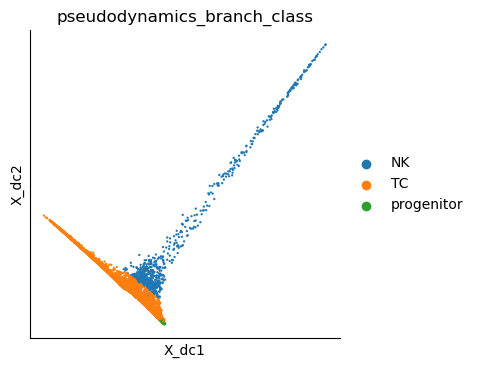

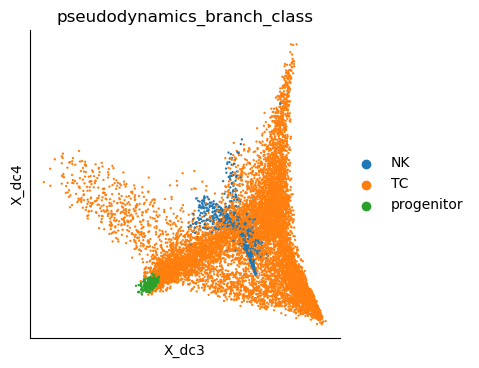

In [8]:
sc.pl.embedding(meahr_raw, components='1,2', basis='X_dc', color='pseudodynamics_branch_class')
sc.pl.embedding(meahr_raw, components='3,4', basis='X_dc', color='pseudodynamics_branch_class')

# run preprocessing

In [9]:
meahr_raw.var_names.str.startswith("MT-").sum(), meahr_raw.var_names.str.startswith(("RPS", "RPL")).sum()

(0, 0)

In [10]:
# Normalizing to median total counts
meahr = meahr_raw.copy()
meahr.raw = sc.pp.log1p(meahr, copy=True)
sc.pp.recipe_weinreb17(meahr, log=True, random_state=0) # Do log-transform.

sc.pp.neighbors(meahr, n_neighbors=100, knn=True, method='umap', n_pcs=50, random_state=0)
sc.tl.diffmap(meahr)
sc.tl.umap(meahr)
sc.tl.tsne(meahr)
# sc.pp.highly_variable_genes(meahr, n_top_genes=2000, batch_key="batch_y")

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


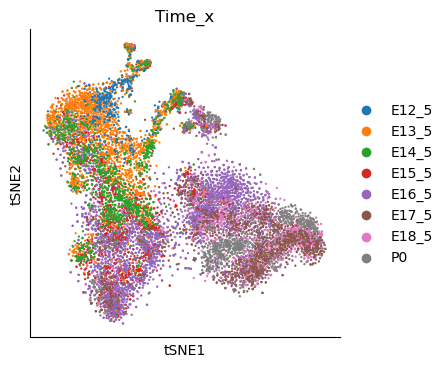

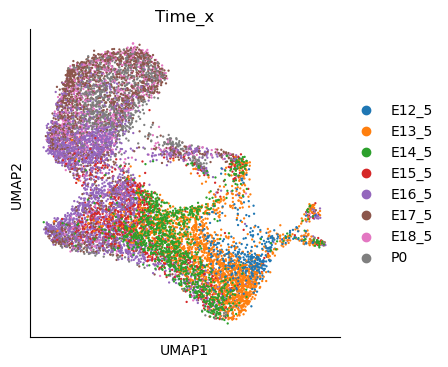

In [14]:
sc.pl.tsne(meahr, color=['Time_x'])
sc.pl.umap(meahr, color=['Time_x'])

In [16]:
sc.pp.neighbors(meahr, n_neighbors=100, knn=False, method='gauss', n_pcs=50, random_state=0)
sc.tl.diffmap(meahr)
sc.tl.dpt(meahr, n_dcs=15)

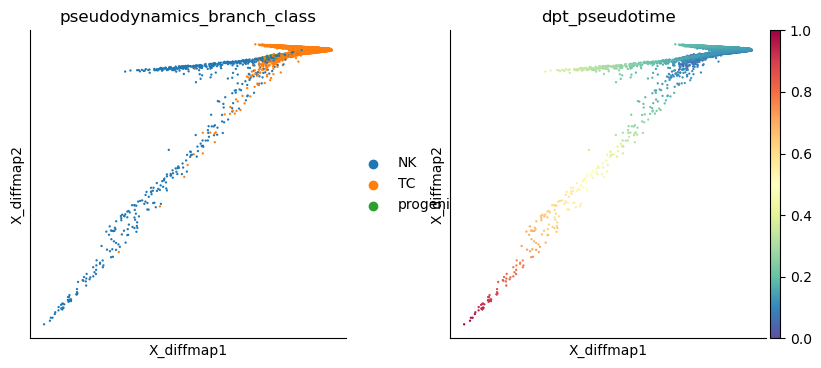

In [18]:
sc.pl.embedding(meahr, components='1,2', basis='X_diffmap', 
                color=['pseudodynamics_branch_class','dpt_pseudotime'])

In [22]:
sc.tl.leiden(meahr, resolution=2.5, flavor='leidenalg', random_state=0)
sc.tl.paga(meahr)

/tmp/ipykernel_2730736/3714475228.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(meahr, resolution=2.5, flavor='leidenalg', random_state=0)


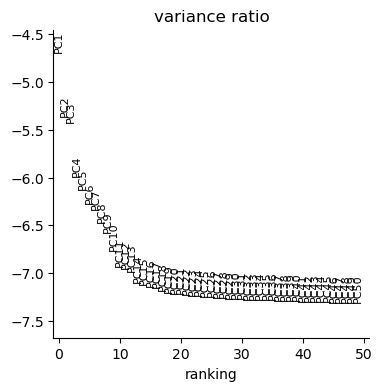

In [19]:
sc.tl.pca(meahr)
sc.pl.pca_variance_ratio(meahr, n_pcs=50, log=True)
sc.pp.neighbors(meahr)

In [72]:
meahr.obs['Time_x'] = meahr.obs_names.str.extract('\w{10,18}\.([E|P]\d{1,2}(_\d)?)')[0].values
meahr.obs['Time_y'] = meahr.obs['batch_to_match'].str.extract('([E|P]\d{1,2}(_\d)?)')[0].values

In [146]:
np.mean(meahr.obs['Time_x'] == meahr.obs['Time_y'])

0.9985046728971962

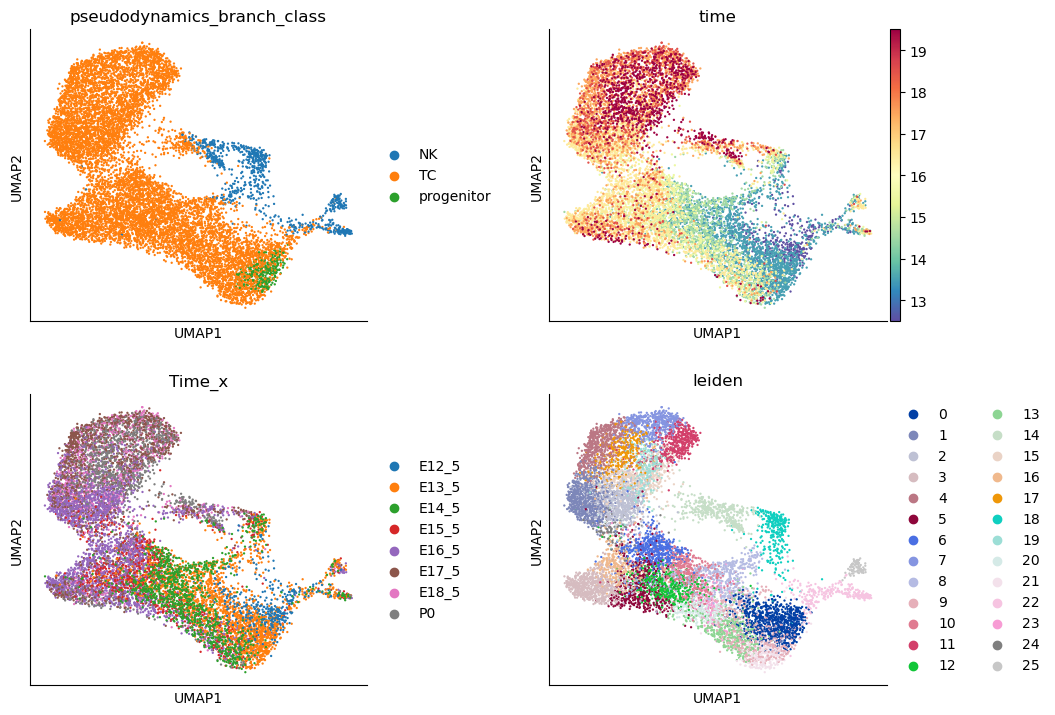

In [23]:
# 
sc.pl.umap(meahr, color=['pseudodynamics_branch_class', 'time', 'Time_x', 'leiden'], ncols=2, wspace=0.4)

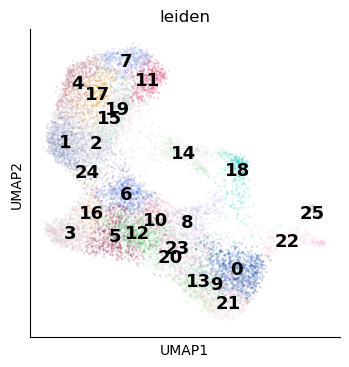

In [24]:
# 
sc.pl.umap(meahr, color=['leiden'], legend_loc='on data', alpha=0.2, legend_fontsize=13)

# find myloid cells

In [39]:
# Leukocyte markers:
leuk_markers = ['Ptprc']
# T-cell markers: 
# CD25=Il2ra
tc_markers = ['Flt3','Cd44', 'Il2ra','Ptcra','Rag1','Rag2','Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Notch1', 'Bcl11b']
cd3_markers = ['Cd3d', 'Cd3e', 'Cd3g']
# alpha-beta T-cell makers (double positives):
ab_tc_markers = ['Id3', 'Rorc','Cd4', 'Cd8a', 'Cd8b1']
# gamma-delta T-cell markers:
yd_tc_markers = ['Ifng', 'Il17a']
# TCR (from separate alignment)
tcr_markers = ['TCRa', 'TCRb', 'TCRy', 'TCRd']
# Natural-killer cell markers
nk_markers = ['Il2rb', 'Ncr1', 'Klrd1', 'Klrb1b', 'Klrb1f']

# Hematopoietic stem cell markers:
sc_markers = ['Cd34']
# Myeloid cell markers: 
# Cd11c=Itgax, CD11b=Itgam, Cd16=Fcgr3
myeloid_markers = ['Itgax', 'Itgam', 'Fcgr3']
# Macrophage/monocyte markers:
# CD11b=Itgam, Ly-71=Adgre1, Lyz2: lysozyme
mp_markers = ['Adgre1', 'Lyz2']
# Dendritic cell markers
# Cd74=Cd74, CD11b=Itgam, CD13=Anpep, CD33=Cd33, CD80h=Cd80, CD83=Cd83, CD86=Cd86
dc_markers = ['Cd74', 'Anpep' , 'Cd33', 'Cd80', 'Cd83', 'Cd86'] 
# B-cell markers
bc_markers = ['Cd19']

leuk_markers = np.array([x for x in leuk_markers if x in meahr.var_names])

tc_markers = np.array([x for x in tc_markers if x in meahr.var_names])
cd3_markers = np.array([x for x in cd3_markers if x in meahr.var_names])
ab_tc_markers = np.array([x for x in ab_tc_markers if x in meahr.var_names])
yd_tc_markers = np.array([x for x in yd_tc_markers if x in meahr.var_names])
nk_markers = np.array([x for x in nk_markers if x in meahr.var_names])

sc_markers = np.array([x for x in sc_markers if x in meahr.var_names])
myeloid_markers = np.array([x for x in myeloid_markers if x in meahr.var_names])
mp_markers = np.array([x for x in mp_markers if x in meahr.var_names])
dc_markers = np.array([x for x in dc_markers if x in meahr.var_names])
bc_markers = np.array([x for x in bc_markers if x in meahr.var_names])

In [147]:
np.concatenate([tc_markers,cd3_markers,yd_tc_markers])

array(['Cd44'], dtype='<U32')

In [148]:
import matplotlib.pyplot as plt

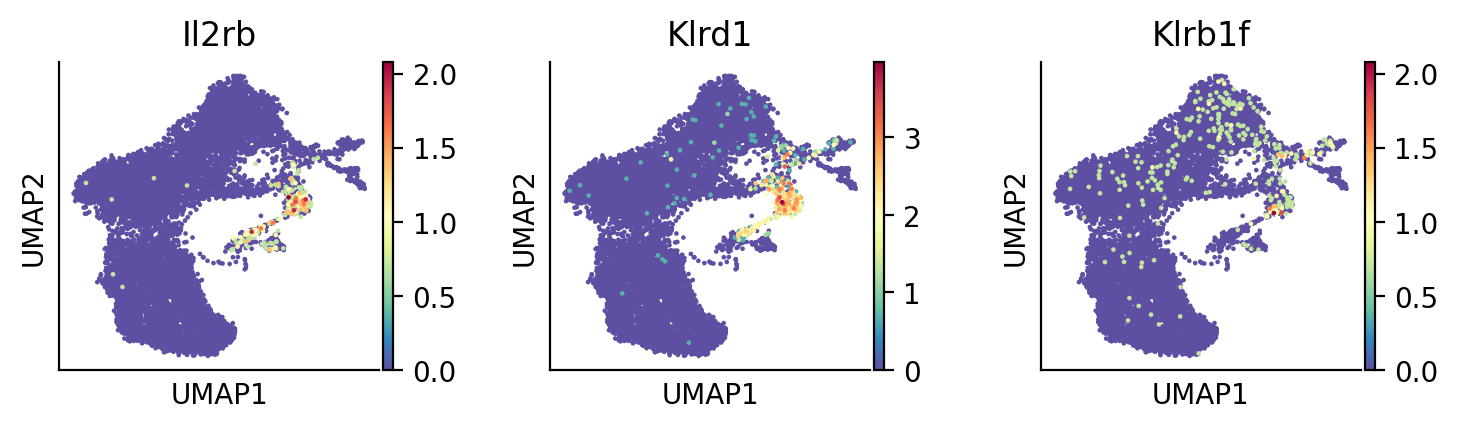

In [149]:
with plt.rc_context({'figure.figsize':(2,2), 'figure.dpi':200}):
    sc.pl.umap(meahr, color=nk_markers)

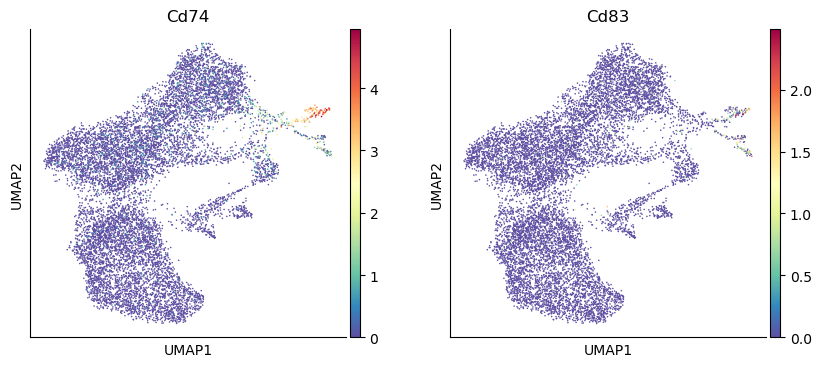

In [ ]:
sc.pl.umap(meahr, color=dc_markers, use_raw=True, size=5)

# run diffmap and pseudotime 

In [29]:
sc.pp.neighbors(meahr, n_neighbors=100, knn=False, method='gauss', n_pcs=50, random_state=0)
sc.tl.diffmap(meahr)
sc.tl.dpt(meahr, n_dcs=15)

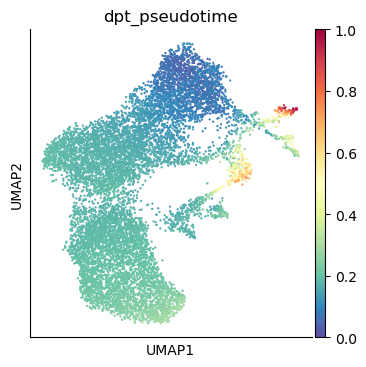

In [30]:
sc.pl.umap(meahr, color=['dpt_pseudotime'])

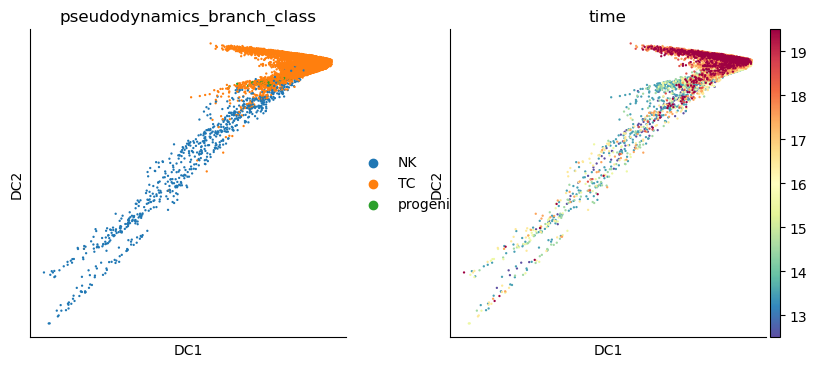

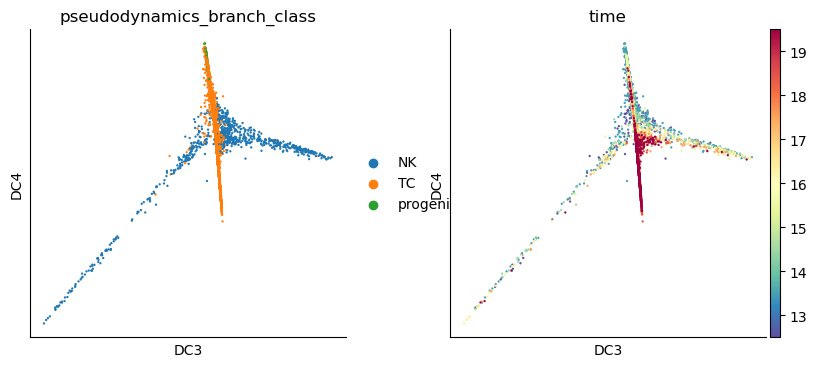

In [88]:
sc.pl.diffmap(meahr, components='1,2', color=['pseudodynamics_branch_class', 'time'])

sc.pl.diffmap(meahr, components='3,4', color=['pseudodynamics_branch_class', 'time'])

In [83]:
meahr.write_h5ad("data/meahr/David_cb.h5ad")

# run palantir

In [5]:
meahr = sc.read_h5ad("data/meahr/David_cb.h5ad")

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [31]:
meahr.obs_names_make_unique()

In [32]:
weird_TC = meahr.obs.query("`pseudodynamics_branch_class` == 'TC' & `leiden` == '14'").index

In [33]:
cell_to_stay = [cb for cb in meahr.obs_names if cb not in weird_TC]
meahr = meahr[cell_to_stay]

In [35]:
meahr.shape[0] , len(np.unique(meahr.obs_names))

(10689, 10689)

In [36]:

meahr.shape[0] , len(np.unique(meahr.obs_names))

(10689, 10689)

In [31]:
sc.pp.neighbors(meahr, n_neighbors=100, knn=True, method='umap', n_pcs=50, random_state=0)

In [37]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(meahr)
ms_data = palantir.utils.determine_multiscale_space(meahr)

imputed_X = palantir.utils.run_magic_imputation(meahr)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/palantir/utils.py:479: ImplicitModificationWarning: Setting element `.obsp['DM_Kernel']` of view, initializing view as actual.
  data.obsp[kernel_key] = res["kernel"]


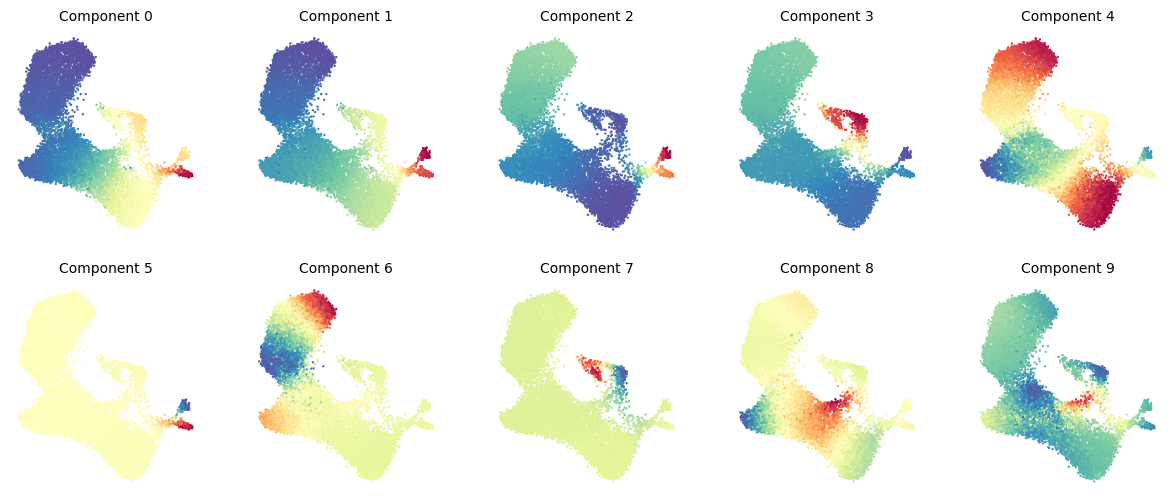

In [38]:
palantir.plot.plot_diffusion_components(meahr);

CGTTGCTCCTTC.P0_WholeThy_rep2
TGTGTCCATTAT.E18_5_WholeThy_rep1
ACCTTAGGCGCC.E12_5_WholeThy_venus_rep3


(<Figure size 400x400 with 1 Axes>, <Axes: >)

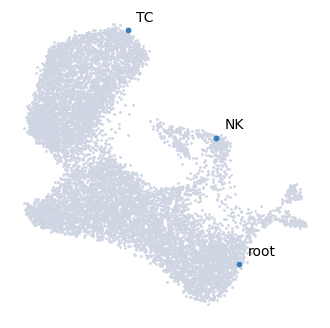

In [42]:
# terminal mk
nk_cells =  meahr.obs.query('`pseudodynamics_branch_class` == "NK" & `Time_x` == "P0"')
nk_terminal_idx = nk_cells.pseudotime.argmax()
nk_terminal_cb = nk_cells.iloc[nk_terminal_idx].name
print(nk_terminal_cb)

# terminal ery
tc_cells =  meahr.obs.query('`pseudodynamics_branch_class` == "TC"')
tc_terminal_idx = tc_cells.pseudotime.argmax()
tc_terminal_cb = tc_cells.iloc[tc_terminal_idx].name
print(tc_terminal_cb)

# root
root_idx = meahr.obs.pseudotime.argmin()
root_cb = meahr.obs.iloc[root_idx].name
print(root_cb)
all_states = pd.Series(
    ["NK", "TC", "root"],
    index=[nk_terminal_cb, tc_terminal_cb, root_cb],
)

terminal_states = pd.Series(
    ["NK", "TC"],
    index=[nk_terminal_cb, tc_terminal_cb],
)
palantir.plot.highlight_cells_on_umap(meahr, all_states)

In [41]:
start_cell = root_cb
pr_res = palantir.core.run_palantir(
    meahr, start_cell, knn=100, num_waypoints=500,  terminal_states=terminal_states
)

Sampling and flocking waypoints...


Time for determining waypoints: 0.018544991811116535 minutes
Determining pseudotime...
Shortest path distances using 100-nearest neighbor graph...
Time for shortest paths: 1.6002137343088785 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9997
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [42]:
meahr

AnnData object with n_obs × n_vars = 10890 × 7102
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'palantir_pseudotime', 'palantir_entropy'
    uns: 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'pseudodynamics_branch_class_colors', 'umap', 'DM_EigenValues', 'palantir_waypoints'
    obsm: 'X_dc', 'X_diffmap', 'X_pca', 'X_umap', 'diff component', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks', 'fated_pdt'
    varm: 'PCs'
    layers: 'Counts', 'MAGIC_imputed_data'
    obsp: 'connectivities', 'distances', 'DM_Kernel', 'DM_Similarity'

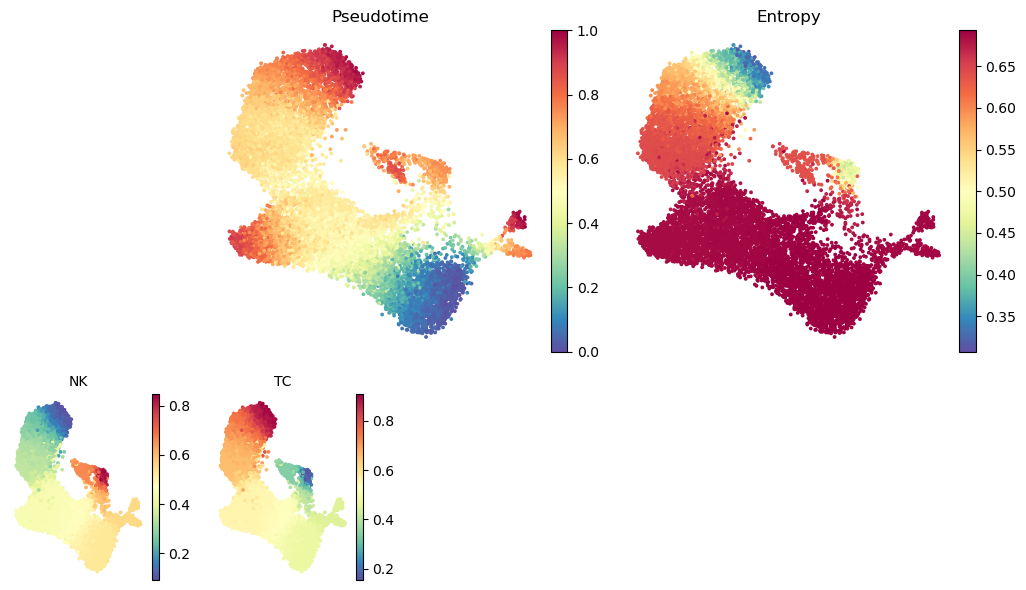

In [43]:
palantir.plot.plot_palantir_results(meahr, s=3);

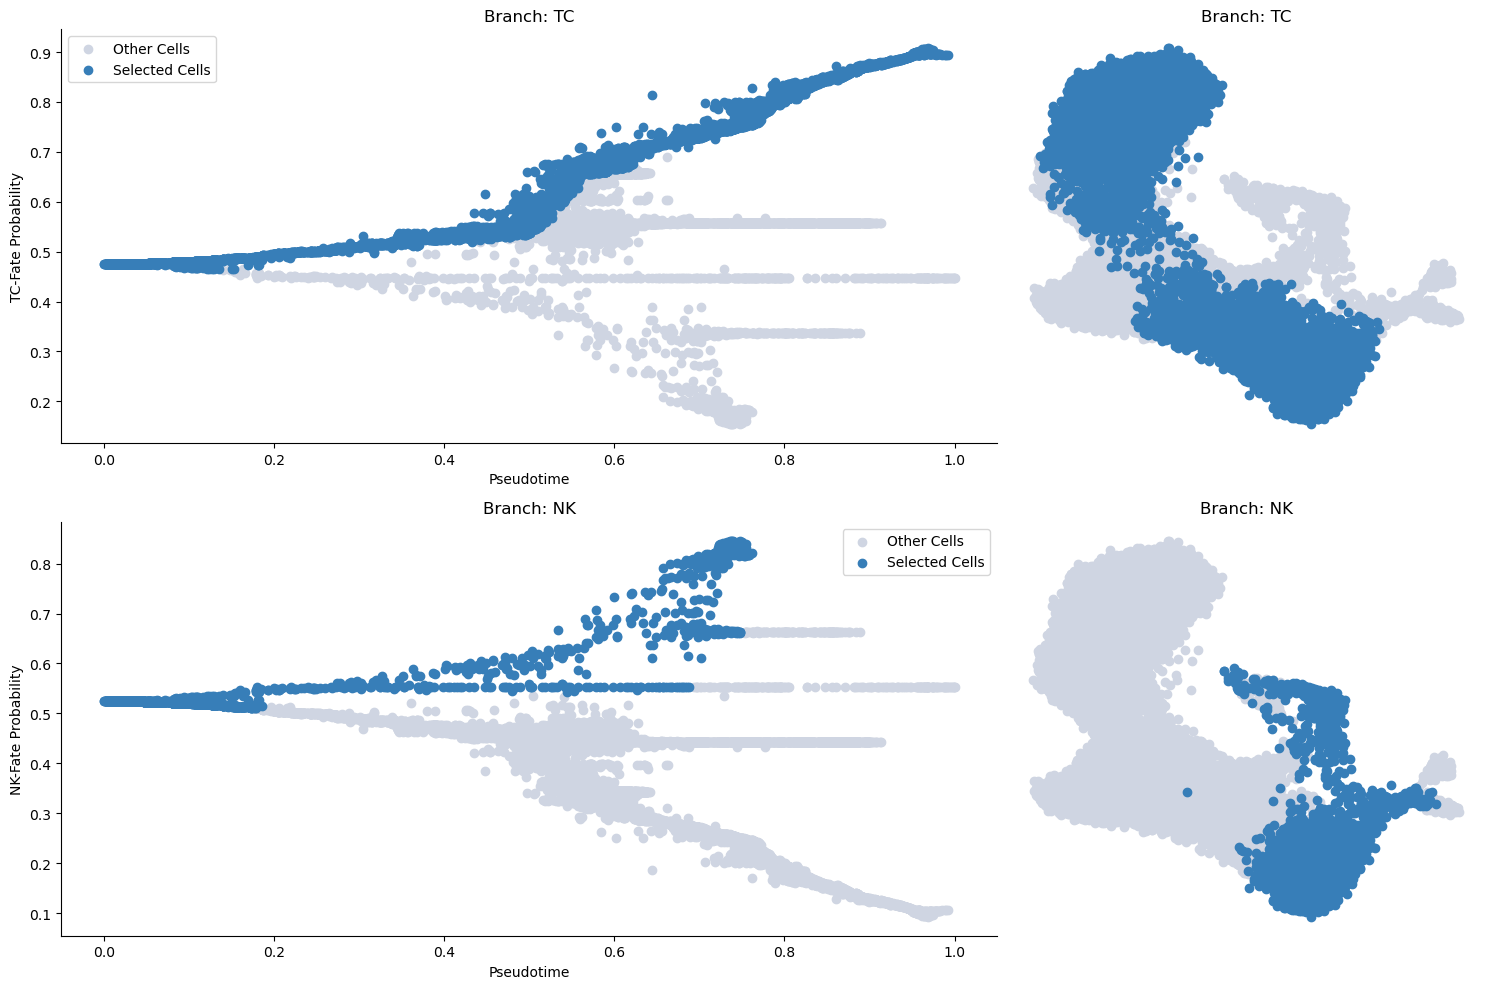

In [44]:
masks = palantir.presults.select_branch_cells(meahr, q=.02, eps=.02)
palantir.plot.plot_branch_selection(meahr);

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[2024-09-20 06:01:06,368] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,083) and rank = 1.0.
[2024-09-20 06:01:06,369] [INFO    ] Using covariance function Matern52(ls=0.9520709991455079).
[2024-09-20 06:01:06,393] [INFO    ] Computing 50 landmarks with k-means clustering.


[2024-09-20 06:01:08,511] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (6,184) and rank = 1.0.
[2024-09-20 06:01:08,513] [INFO    ] Using covariance function Matern52(ls=0.9520709991455079).
[2024-09-20 06:01:08,539] [INFO    ] Computing 50 landmarks with k-means clustering.


<Axes: title={'center': 'Branch: TC'}>

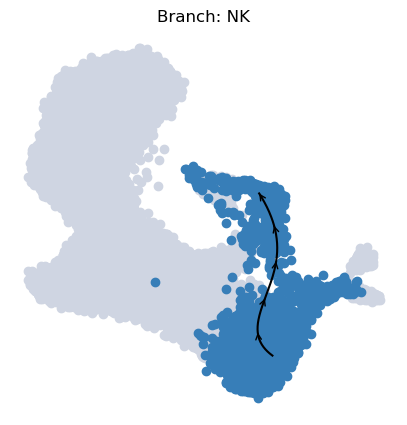

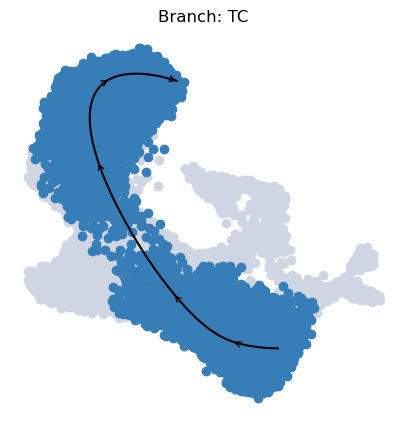

In [45]:
palantir.plot.plot_trajectory(meahr, "NK")
palantir.plot.plot_trajectory(meahr, "TC")

In [46]:
meahr.obsm['DM_EigenVectors_multiscaled'].min(axis=0), meahr.obsm['DM_EigenVectors_multiscaled'].max(axis=0)

(array([-0.9222799 , -0.54326487, -0.49323058, -0.5064444 , -1.5601327 ,
        -0.27068347, -0.4719865 , -0.2974134 ], dtype=float32),
 array([4.165589  , 3.2159688 , 2.187161  , 0.3786613 , 1.6160254 ,
        0.3666682 , 0.7348019 , 0.32189626], dtype=float32))

In [47]:
meahr.obsm['fated_pdt'] = np.multiply(meahr.obsm['palantir_fate_probabilities'].values , meahr.obs['palantir_pseudotime'].values.reshape(-1,1))

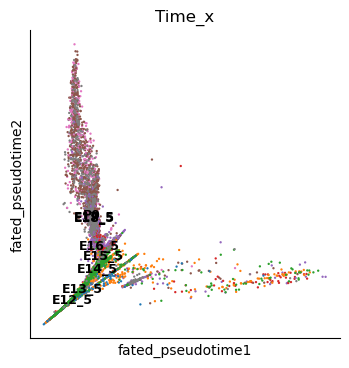

In [50]:
meahr.obsm['fated_pseudotime'] = np.multiply(meahr.obsm['palantir_fate_probabilities'].values , meahr.obs['pseudotime'].values.reshape(-1,1))
sc.pl.embedding(meahr, basis='fated_pseudotime', color=['Time_x'], legend_loc='on data', legend_fontsize=9)

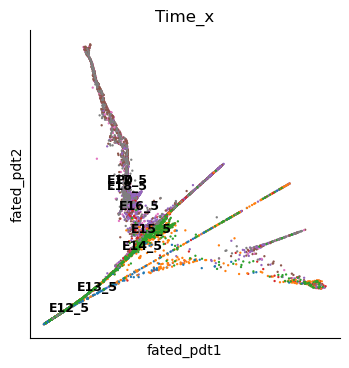

In [51]:
meahr.obsm['fated_pdt'] = np.multiply(meahr.obsm['palantir_fate_probabilities'].values , meahr.obs['palantir_pseudotime'].values.reshape(-1,1))
sc.pl.embedding(meahr, basis='fated_pdt', color=['Time_x'], legend_loc='on data', legend_fontsize=9)

# fate related genes

In [52]:
from scipy.stats import pearsonr
from tqdm.auto import tqdm

In [53]:
meahr

AnnData object with n_obs × n_vars = 10689 × 6650
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'palantir_pseudotime', 'palantir_entropy'
    uns: 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'pseudodynamics_branch_class_colors', 'umap', 'tsne', 'DM_EigenValues', 'palantir_waypoints'
    obsm: 'X_dc', 'X_diffmap', 'X_pca', 'X_umap', 'diff component', 'X_tsne', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks', 'fated_pdt', 'fated_pseudotime'
    varm: 'PCs'
    layers: 'Counts', 'MAGIC_imputed_data'
    obsp: 'connectivities', 'distances', 'DM_Kernel', 'DM_S

In [57]:
TC_ad = meahr[meahr.obsm['branch_masks']['TC']]
pseudotime = TC_ad.obs.palantir_pseudotime.values.reshape(-1,1)
expression = TC_ad.layers['MAGIC_imputed_data']

TC_R = []
i = 0
for i in tqdm(range(TC_ad.shape[1])):
    TC_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
TC_R = np.array(TC_R)
TC_R = np.where(np.isnan((TC_R)), 0, TC_R)
meahr.var['TC_X_pdt_r'] = TC_R

  0%|          | 0/6650 [00:00<?, ?it/s]

/tmp/ipykernel_2730736/2172677534.py:11: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  TC_ad.var['TC_X_pdt_r'] = TC_R


In [62]:
TC_top_genes = meahr.var[['TC_X_pdt_r']].sort_values('TC_X_pdt_r', ascending=False)
TC_genes = TC_top_genes.iloc[:10].index
TC_top_genes.head()

,TC_X_pdt_r
Gene,
Grap2,0.984392
Rapgef3,0.983788
Gm6961,0.973604
Cbl,0.973353
Tapt1,0.967390


## NK

In [64]:
NK_ad = meahr[meahr.obsm['branch_masks']['NK']]
pseudotime = NK_ad.obs.palantir_pseudotime.values.reshape(-1,1)
expression = NK_ad.layers['MAGIC_imputed_data']

NK_R = []
i = 0
for i in tqdm(range(NK_ad.shape[1])):
    NK_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
NK_R = np.array(NK_R)
NK_R = np.where(np.isnan((NK_R)), 0, NK_R)
meahr.var['NK_X_pdt_r'] = NK_R

  0%|          | 0/6650 [00:00<?, ?it/s]

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [65]:
NK_top_genes = meahr.var[['NK_X_pdt_r']].sort_values('NK_X_pdt_r', ascending=False)
NK_genes = NK_top_genes.iloc[:10].index
NK_top_genes.head()

,NK_X_pdt_r
Gene,
Skil,0.978870
Zbp1,0.974083
Nek7,0.972212
Prkx,0.970924
Lpxn,0.968793


In [69]:
import matplotlib.pyplot as plt

In [75]:
s_nk = meahr[:,'Skil'].X.copy().flatten()

In [85]:
gene_iloc=list(meahr.var_names).index("Zbp1")
s_nk = meahr.layers['MAGIC_imputed_data'][:,gene_iloc].copy().flatten()

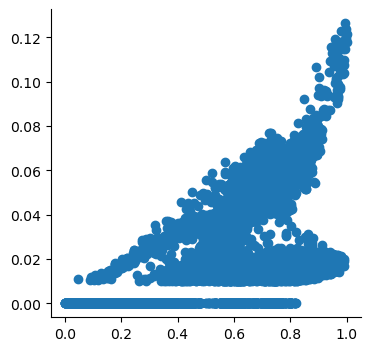

In [86]:
plt.scatter(meahr.obs['palantir_pseudotime'].values, s_nk)

array([0.7114054838, 0.8570088697, 0.7164784525, ..., 0.7171996935,
       0.9233044574, 0.7061944709])

In [63]:
palantir.plot.plot_trend(meahr, "TC", "Grap2", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(meahr, "TC", "Rapgef3", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(meahr, "TC", "Gm6961", color="branch", position_layer="MAGIC_imputed_data")
plt.show()

KeyError: 'gene_trends_TC not found in ad.varm'

In [87]:
S = meahr[:,['Grap2', 'Zbp1']].layers['MAGIC_imputed_data']

In [89]:
meahr.obsm['X_Grap2_Zbp1'] = S.copy()

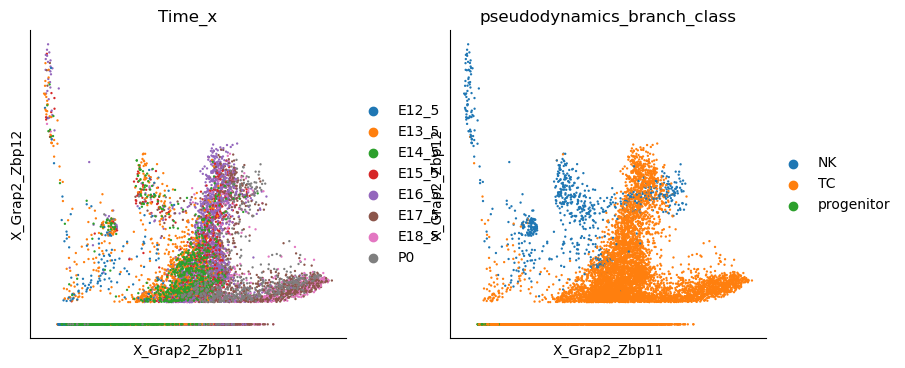

In [91]:
sc.pl.embedding(meahr, basis='X_Grap2_Zbp1', color=['Time_x', 'pseudodynamics_branch_class'])

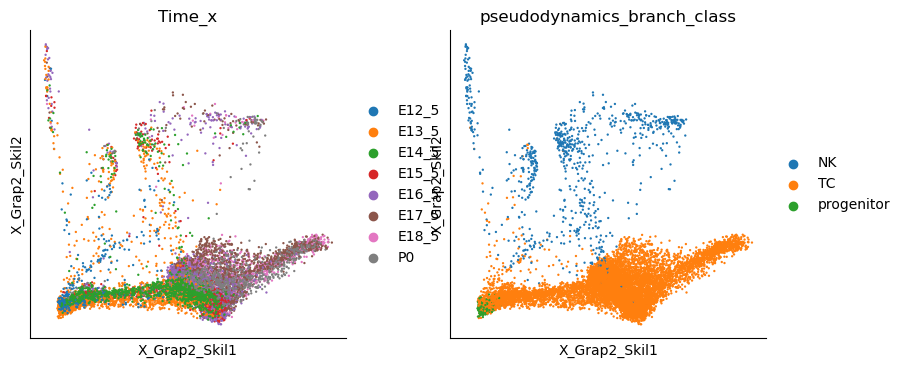

In [ ]:
sc.pl.embedding(meahr, basis='X_Grap2_Skil', color=['Time_x', 'pseudodynamics_branch_class'])

In [92]:
meahr.write_h5ad("data/reprocessed_connected_David-Sep19.h5ad")